In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import random
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score


class CONFIG:
    TRAIN_PATH = "C:/Users/wikto/Desktop/Google summer of code/dataset/train"
    VAL_PATH = "C:/Users/wikto/Desktop/Google summer of code/dataset/val"

    BATCH_SIZE = 64    
    LEARNING_RATE = 1e-4
    EPOCHS = 10
    DROPOUT = 0.3   
    MODEL_NAME = 'densenet161'
    DEVICE = "cpu"
    RANDOM_SEED = 58

np.random.seed(CONFIG.RANDOM_SEED)
torch.manual_seed(CONFIG.RANDOM_SEED)

def get_metadata(path):
    main_path = Path(path)
    classes = sorted([f.name for f in main_path.iterdir() if f.is_dir()])
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    
    image_paths = []
    for cls in classes:
        image_paths.extend(list((main_path / cls).glob("*.npy")))
    
    return image_paths, classes, class_to_idx

train_paths, classes, class_to_idx = get_metadata(CONFIG.TRAIN_PATH)
val_paths, _, _ = get_metadata(CONFIG.VAL_PATH)
idx_to_class = {v: k for k, v in class_to_idx.items()}


class GSoCDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = np.load(path)
        
        if len(image.shape) == 2:
            image = np.expand_dims(image, axis=0)
        
        image = torch.from_numpy(image).float()
        label = class_to_idx[Path(path).parent.name]
        return image, label


train_loader = DataLoader(GSoCDataset(train_paths), batch_size=CONFIG.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(GSoCDataset(val_paths), batch_size=CONFIG.BATCH_SIZE, shuffle=False)

class DenseNet161Model(nn.Module):
    def __init__(self, n_classes=3):
        super(DenseNet161Model, self).__init__()
        self.transfer_learning_model = timm.create_model('densenet161', pretrained=True, in_chans=1)
        for param in self.transfer_learning_model.parameters():
            param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(2208 * 4 * 4, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=CONFIG.DROPOUT),
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(p=CONFIG.DROPOUT),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.transfer_learning_model.forward_features(x)
        x = x.view(-1, 2208 * 4 * 4)
        x = self.classifier(x)
        return x

def train_one_epoch(model, optimizer, criterion, loader):
    model.train()
    losses = []
    correct, total = 0, 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(CONFIG.DEVICE, non_blocking=True), labels.to(CONFIG.DEVICE, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    return 100 * correct / total, np.mean(losses)

def validate(model, criterion, loader):
    model.eval()
    losses = []
    correct, total = 0, 0
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(CONFIG.DEVICE, non_blocking=True), labels.to(CONFIG.DEVICE, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            
            losses.append(loss.item())
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return 100 * correct / total, np.mean(losses), np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [ ]:
#run
model = DenseNet161Model(n_classes=len(classes)).to(CONFIG.DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_acc = 0

for epoch in range(CONFIG.EPOCHS):
    print(f"\nEpoch {epoch+1}/{CONFIG.EPOCHS}")
    t_acc, t_loss = train_one_epoch(model, optimizer, criterion, train_loader)
    v_acc, v_loss, y_true, y_pred, y_prob = validate(model, criterion, val_loader)
    
    
    print(f"Train Loss: {t_loss} | Acc: {t_acc}%")
    print(f"Val Loss: {v_loss} | Acc: {v_acc}%")
    
    scheduler.step(v_acc)
    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'models/densenet161_best.pth')
        print("New best, saved")

In [6]:
#loading model again if neccessary


def get_predictions(model_path, data_loader):
    model = DenseNet161Model(n_classes=3).to(CONFIG.DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=CONFIG.DEVICE))
    model.eval()
    
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Preds"):
            images = images.to(CONFIG.DEVICE)
            
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_probs)

val_loader = DataLoader(GSoCDataset(val_paths), batch_size=CONFIG.BATCH_SIZE, shuffle=False)

y_true, y_probs = get_predictions(
    model_path='models/densenet161_best.pth', 
    data_loader=val_loader
)


Preds: 100%|██████████| 118/118 [17:27<00:00,  8.88s/it]


              precision    recall  f1-score   support

          no       0.88      0.96      0.92      2500
      sphere       0.90      0.86      0.88      2500
        vort       0.95      0.91      0.93      2500

    accuracy                           0.91      7500
   macro avg       0.91      0.91      0.91      7500
weighted avg       0.91      0.91      0.91      7500

AUC for no: 0.9846
AUC for sphere: 0.9695
AUC for vort: 0.9858


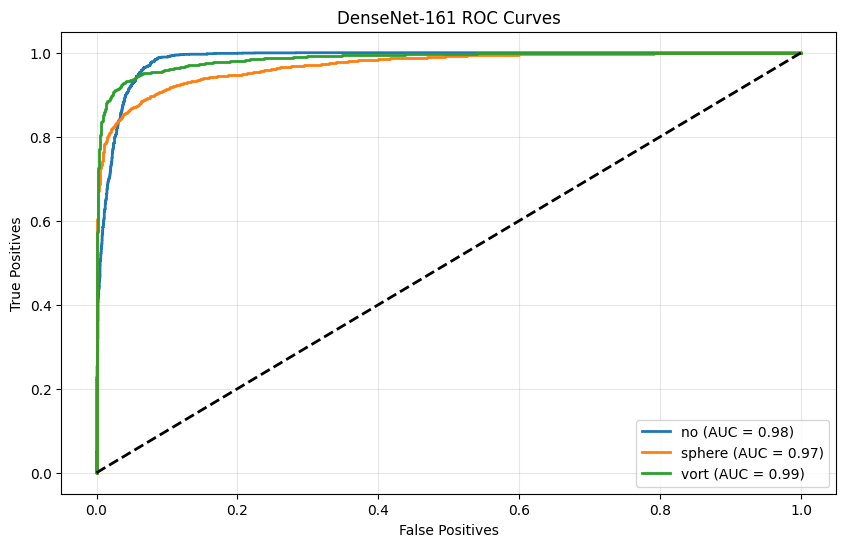

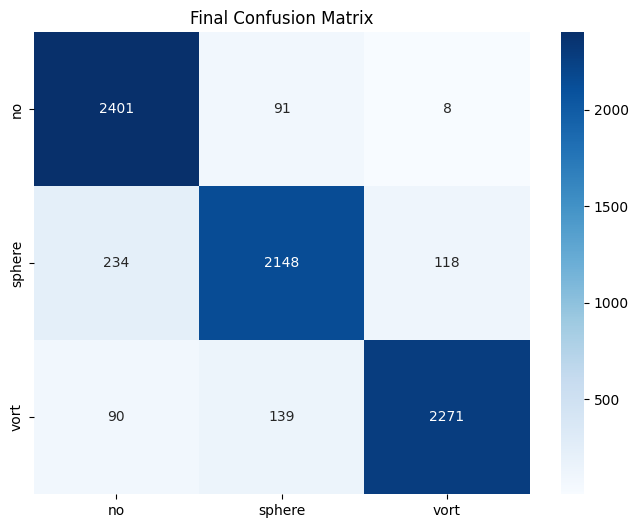

In [9]:
#results

y_pred = np.argmax(y_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=classes))

plt.figure(figsize=(10, 6))
y_true_onehot = np.eye(len(classes))[y_true]
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {auc(fpr, tpr):.2f})')


auc_per_class = roc_auc_score(y_true_onehot, y_probs, average=None)
for i, class_name in enumerate(classes):
    print(f"AUC for {class_name}: {auc_per_class[i]:.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('DenseNet-161 ROC Curves')
plt.xlabel('False Positives')
plt.ylabel('True Positives')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix')
plt.show()